Data preview and importing — Requirement 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from IPython.display import display

In [2]:
df = pd.read_csv("insurance.csv")
display(df.head())
print("Rows and columns:", df.shape)
df.info()
display(df.describe())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Rows and columns: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Checking null — Requirement 2

The file contains no missing values, so no imputation or removal for missing data is needed.

In [3]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Basic Description and visualisation

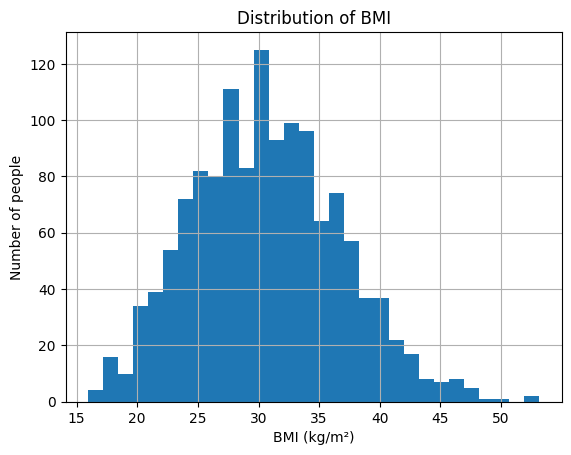

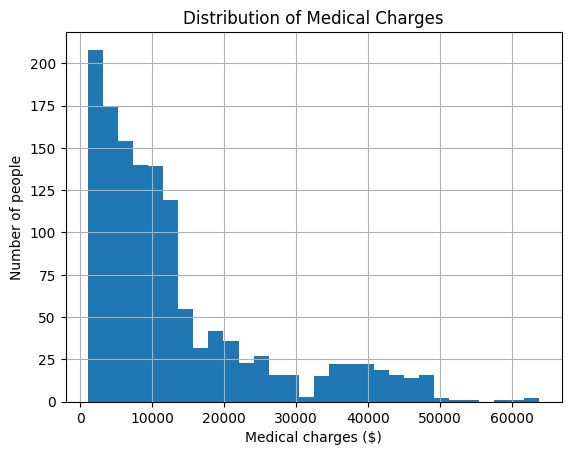

In [4]:
df["bmi"].hist(bins=30)
plt.title("Distribution of BMI")
plt.xlabel("BMI (kg/m²)")
plt.ylabel("Number of people")
plt.show()

df["charges"].hist(bins=30)
plt.title("Distribution of Medical Charges")
plt.xlabel("Medical charges ($)")
plt.ylabel("Number of people")
plt.show()

Data cleaning — Requirement 3

No missing values or inconsistent category labels were found, and no obvious errors were established. There is little to clean: we remove one exact duplicate below as requested in the assignment.

Kaggle defines `children` as children covered by health insurance / number of dependents. Age and dependent count alone do not establish an error, so these records are retained. Plausible extreme BMI and charges are also retained, and the original CSV stays unchanged.

Source: [Kaggle dataset description](https://www.kaggle.com/datasets/mirichoi0218/insurance).

In [5]:
# Keep all records before checking exact duplicates.
df_clean = df.copy()

Duplicate rows

Remove exact duplicate rows as requested in the assignment. Matching all seven values does not establish that two records belong to the same person.

In [6]:
print("Duplicate rows:", df_clean.duplicated().sum())

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Original rows:", len(df))
print("Remaining rows:", len(df_clean))

Duplicate rows: 1
Original rows: 1338
Remaining rows: 1337


Using the IQR rule for potential outliers — Requirement 5

We inspect BMI and charges in their original units before scaling. The IQR rule flags unusual values, not confirmed errors. High medical costs and high BMI can be plausible, so we retain these rows. Median and IQR summaries reduce the influence of extremes when describing the data. This is our outlier-handling decision; it does not make future models automatically robust.

In [7]:
columns = ["bmi", "charges"]

Q1 = df_clean[columns].quantile(0.25)
Q3 = df_clean[columns].quantile(0.75)
IQR = Q3 - Q1

outliers = (
    (df_clean[columns] < Q1 - 1.5 * IQR) |
    (df_clean[columns] > Q3 + 1.5 * IQR)
)

outliers.sum()

bmi          9
charges    139
dtype: int64

In [8]:
df_clean.loc[outliers.any(axis=1)].head(10)

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.13,0,yes,southeast,39611.75770
19,30,male,35.30,0,yes,southwest,36837.46700
23,34,female,31.92,1,yes,northeast,37701.87680
29,31,male,36.30,2,yes,southwest,38711.00000
30,22,male,35.60,0,yes,southwest,35585.57600
34,28,male,36.40,1,yes,southwest,51194.55914
38,35,male,36.67,1,yes,northeast,39774.27630
39,60,male,39.90,0,yes,southwest,48173.36100
49,36,male,35.20,1,yes,southeast,38709.17600
53,36,male,34.43,0,yes,southeast,37742.57570


In [9]:
# Keep plausible extremes instead of deleting every IQR-flagged row.
print("Rows flagged in either column:", outliers.any(axis=1).sum())
print("Rows removed for outliers: 0")

robust_summary = pd.DataFrame({
    "Median": df_clean[columns].median(),
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR
})
robust_summary.round(2)

Rows flagged in either column: 145
Rows removed for outliers: 0


,Median,Q1,Q3,IQR
bmi,30.40,26.29,34.70,8.41
charges,9386.16,4746.34,16657.72,11911.37


Feature engineering — Requirement 6

`bmi_category` groups BMI values for comparisons, and `has_children` identifies people with at least one covered dependent. These are the only two engineered features. Fixed adult BMI bands are a classroom simplification for ages 18–19, not a clinical assessment.

We engineer features before the final encoding/scaling pass so the saved files include them.

In [10]:
df_clean["bmi_category"] = pd.cut(
    df_clean["bmi"],
    bins=[0, 18.5, 25, 30, 35, 40, float("inf")],
    labels=[
        "Underweight",
        "Healthy weight",
        "Overweight",
        "Obesity class 1",
        "Obesity class 2",
        "Obesity class 3"
    ],
    right=False
)

df_clean["has_children"] = (df_clean["children"] > 0).astype(int)

In [11]:
df_clean[["bmi", "bmi_category", "children", "has_children"]].head()

,bmi,bmi_category,children,has_children
0,27.900,Overweight,0,0
1,33.770,Obesity class 1,1,1
2,33.000,Obesity class 1,3,1
3,22.705,Healthy weight,0,0
4,28.880,Overweight,0,0


Encoding categorical features — Requirement 4

Encode sex and smoking status as 0/1, and one-hot encode region and BMI category. `has_children` is already binary. Derived features repeat some information from their source columns; later modelling will choose an appropriate subset.

In [12]:
df_encoded = df_clean.copy()

df_encoded["sex"] = df_encoded["sex"].map({"female": 0, "male": 1})
df_encoded["smoker"] = df_encoded["smoker"].map({"no": 0, "yes": 1})

df_encoded = pd.get_dummies(
    df_encoded, columns=["region", "bmi_category"], dtype=int
)

df_encoded.head()

,age,sex,bmi,children,smoker,charges,has_children,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Healthy weight,bmi_category_Overweight,bmi_category_Obesity class 1,bmi_category_Obesity class 2,bmi_category_Obesity class 3
0,19,0,27.900,0,1,16884.92400,0,0,0,0,1,0,0,1,0,0,0
1,18,1,33.770,1,0,1725.55230,1,0,0,1,0,0,0,0,1,0,0
2,28,1,33.000,3,0,4449.46200,1,0,0,1,0,0,0,0,1,0,0
3,33,1,22.705,0,0,21984.47061,0,0,1,0,0,0,1,0,0,0,0
4,32,1,28.880,0,0,3866.85520,0,0,1,0,0,0,0,1,0,0,0


Standardizing numerical features — Requirement 4

Scale age, BMI and children; retain binary columns as 0/1 and charges in original units. This is a preprocessing exercise. For predictive modelling later, split first and fit the scaler on training data only.

In [13]:
df_scaled = df_encoded.copy()

columns_to_scale = ["age", "bmi", "children"]

scaler = StandardScaler()
df_scaled[columns_to_scale] = scaler.fit_transform(
    df_encoded[columns_to_scale]
)

df_scaled.head()

,age,sex,bmi,children,smoker,charges,has_children,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Healthy weight,bmi_category_Overweight,bmi_category_Obesity class 1,bmi_category_Obesity class 2,bmi_category_Obesity class 3
0,-1.440418,0,-0.453160,-0.909234,1,16884.92400,0,0,0,0,1,0,0,1,0,0,0
1,-1.511647,1,0.509422,-0.079442,0,1725.55230,1,0,0,1,0,0,0,0,1,0,0
2,-0.799350,1,0.383155,1.580143,0,4449.46200,1,0,0,1,0,0,0,0,1,0,0
3,-0.443201,1,-1.305052,-0.909234,0,21984.47061,0,0,1,0,0,0,1,0,0,0,0
4,-0.514431,1,-0.292456,-0.909234,0,3866.85520,0,0,1,0,0,0,0,1,0,0,0


In [14]:
df_scaled[columns_to_scale].agg(["mean", "std"]).round(2)

,age,bmi,children
mean,-0.0,-0.0,0.0
std,1.0,1.0,1.0


Saving the final cleaned and preprocessed files

In [15]:
# Save once, after cleaning, outlier review and feature engineering.
# The original insurance.csv stays unchanged.
df_clean.to_csv("insurance_cleaned.csv", index=False)
df_scaled.to_csv("insurance_preprocessed.csv", index=False)

Visuals and comparisons — Requirement 7

In [16]:
clean = pd.read_csv("insurance_cleaned.csv")
processed = pd.read_csv("insurance_preprocessed.csv")

Distribution of medical charges

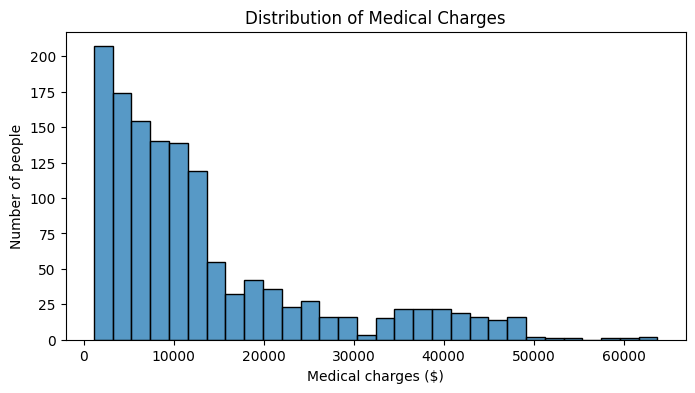

In [17]:
plt.figure(figsize=(8, 4))

sns.histplot(data=clean, x="charges", bins=30)

plt.title("Distribution of Medical Charges")
plt.xlabel("Medical charges ($)")
plt.ylabel("Number of people")
plt.show()

BMI versus charges, comparing smokers and non-smokers

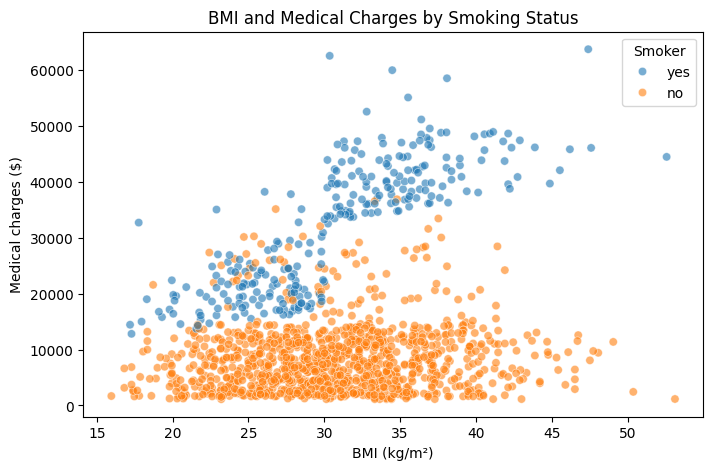

In [18]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=clean,
    x="bmi",
    y="charges",
    hue="smoker",
    alpha=0.6
)

plt.title("BMI and Medical Charges by Smoking Status")
plt.xlabel("BMI (kg/m²)")
plt.ylabel("Medical charges ($)")
plt.legend(title="Smoker")
plt.show()

Average charges by BMI category

,count,mean
bmi_category,,
Underweight,20,8852.20
Healthy weight,225,10409.34
Overweight,386,10987.51
Obesity class 1,390,14452.44
Obesity class 2,225,17022.26
Obesity class 3,91,16784.62


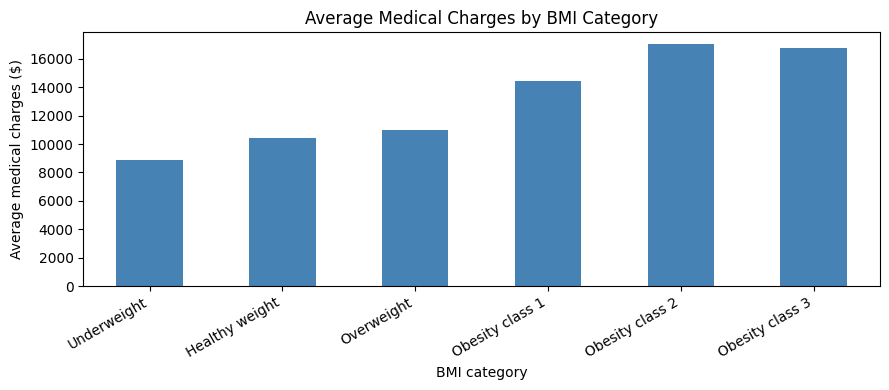

In [19]:
category_order = [
    "Underweight",
    "Healthy weight",
    "Overweight",
    "Obesity class 1",
    "Obesity class 2",
    "Obesity class 3"
]

summary = clean.groupby("bmi_category")["charges"].agg(
    ["count", "mean"]
).reindex(category_order)

display(summary.round(2))

summary["mean"].dropna().plot(
    kind="bar", figsize=(9, 4), color="steelblue"
)

plt.title("Average Medical Charges by BMI Category")
plt.xlabel("BMI category")
plt.ylabel("Average medical charges ($)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Correlation heatmap using the preprocessed file

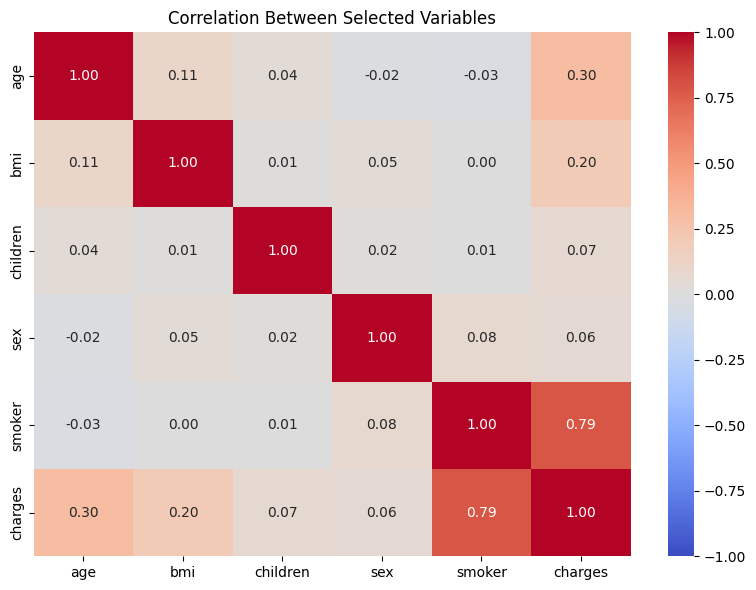

In [20]:
columns = ["age", "bmi", "children", "sex", "smoker", "charges"]

correlations = processed[columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Correlation Between Selected Variables")
plt.tight_layout()
plt.show()

The heatmap shows linear relationships. Red indicates positive correlation, blue indicates negative correlation, and values near zero indicate little linear relationship.

Smoking status has the strongest correlation with charges (**0.79**), followed by age (**0.30**) and BMI (**0.20**). Number of dependents (**0.07**) and sex (**0.06**) show weak linear relationships with charges. Standardization does not change Pearson correlations.

These results describe **1,337 retained records** after removing one exact duplicate. No records were excluded based on age, dependent count, BMI or charges. Plausible extremes were kept. Correlation does not establish causation, and relationships may differ within groups.